<a href="https://colab.research.google.com/github/COMP3608-Group-12/Project/blob/Decision-Tree-Algorithm-on-Dataset-2/Group_12_Dataset_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
#Initial Test Commit

## STEP 1: Importing Packages

In [5]:
#importing packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import imblearn

## STEP 2: Load & Understand Data

In [6]:
#loading csv file into pandas dataframe
df = pd.read_csv('card_transdata.csv')

#printing dataset information (how many rows, columns etc)
print(df.info())
print('----------------------------------------------------------')

#checking if any values are missing
print(df.isnull().sum())
print('----------------------------------------------------------')

#printing first 5 rows of data to ensure it correlates with datafile
print(df.head(5))
print('----------------------------------------------------------')

#checking how many transactions are fraudulent and how many are non-fraudulent
print(df['fraud'].value_counts())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 8 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   distance_from_home              1000000 non-null  float64
 1   distance_from_last_transaction  1000000 non-null  float64
 2   ratio_to_median_purchase_price  1000000 non-null  float64
 3   repeat_retailer                 1000000 non-null  float64
 4   used_chip                       1000000 non-null  float64
 5   used_pin_number                 1000000 non-null  float64
 6   online_order                    1000000 non-null  float64
 7   fraud                           1000000 non-null  float64
dtypes: float64(8)
memory usage: 61.0 MB
None
----------------------------------------------------------
distance_from_home                0
distance_from_last_transaction    0
ratio_to_median_purchase_price    0
repeat_retailer                   0
used_chip 

## Step 3: Split Data (80/20)

In [7]:
#Splitting features and target
X = df.drop('fraud', axis=1)
y = df['fraud']

#Splitting the data into training and test data 80/20 split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Before Resampling:")
print(y_train.value_counts())

Before Resampling:
fraud
0.0    730078
1.0     69922
Name: count, dtype: int64


## Step 4: Apply SMOTE to balance the data

In [8]:
from imblearn.over_sampling import SMOTE

# Apply SMOTE to the training data(to balance)
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("After Resampling(SMOTE):")
print(y_train_resampled.value_counts())

After Resampling(SMOTE):
fraud
0.0    730078
1.0    730078
Name: count, dtype: int64


## Step 5: Decision Tree Model

### Step 5a: Training the Decision Tree Model

In [9]:
#Training Decision Tree Model
from sklearn.tree import DecisionTreeClassifier, plot_tree

model = DecisionTreeClassifier(random_state=42)
model.fit(X_train_resampled, y_train_resampled)

#NOTE: the hyperparameters for the DecisionTreeClassifier were chosen through trial and error (ended up being none)
#Possible future enhancements can be to possibly do hyperparameter tuning using GridSearchCV or RandomizedSearchCV

DecisionTreeClassifier(random_state=42)

### Step 5b: Make Predictions

In [10]:
#Predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

y_pred_train = model.predict(X_train_resampled)
y_prob_train = model.predict_proba(X_train_resampled)[:, 1]

### Step 5c: Evaluating the model using performance metrics

In [11]:
#Evaluating the model using performance metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix

#Calculating performance metrics
results = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1 Score': f1_score(y_test, y_pred),
    'ROC-AUC': roc_auc_score(y_test, y_prob)
}

#Printing results in an easy to read table
results_df = pd.DataFrame({"Metric": list(results.keys()), "Value": [round(value, 4) for value in results.values()]})
print(results_df)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("Classification Report:")
print(classification_report(y_test, y_pred, digits=4))

      Metric   Value
0   Accuracy  1.0000
1  Precision  0.9998
2     Recall  0.9998
3   F1 Score  0.9998
4    ROC-AUC  0.9999
Confusion Matrix:
[[182515      4]
 [     3  17478]]
Classification Report:
              precision    recall  f1-score   support

         0.0     1.0000    1.0000    1.0000    182519
         1.0     0.9998    0.9998    0.9998     17481

    accuracy                         1.0000    200000
   macro avg     0.9999    0.9999    0.9999    200000
weighted avg     1.0000    1.0000    1.0000    200000



### Step 5d: Checking for Overfitting
Decision Trees are prone to overfitting i.e. the model performs much better on the training data than it does on the test data.

Hence, we will check if it generalizes well by comparing the accuracy metrics of how the model performed on both the training and test data.

In [12]:
print("Accuracy of Model on Train Data:")
print(round(accuracy_score(y_train_resampled, y_pred_train), 4))

print("Accuracy of Model on Test Data:")
print(round(accuracy_score(y_test, y_pred), 4))


Accuracy of Model on Train Data:
1.0
Accuracy of Model on Test Data:
1.0


### Step 5e: Visualising the Decision Tree

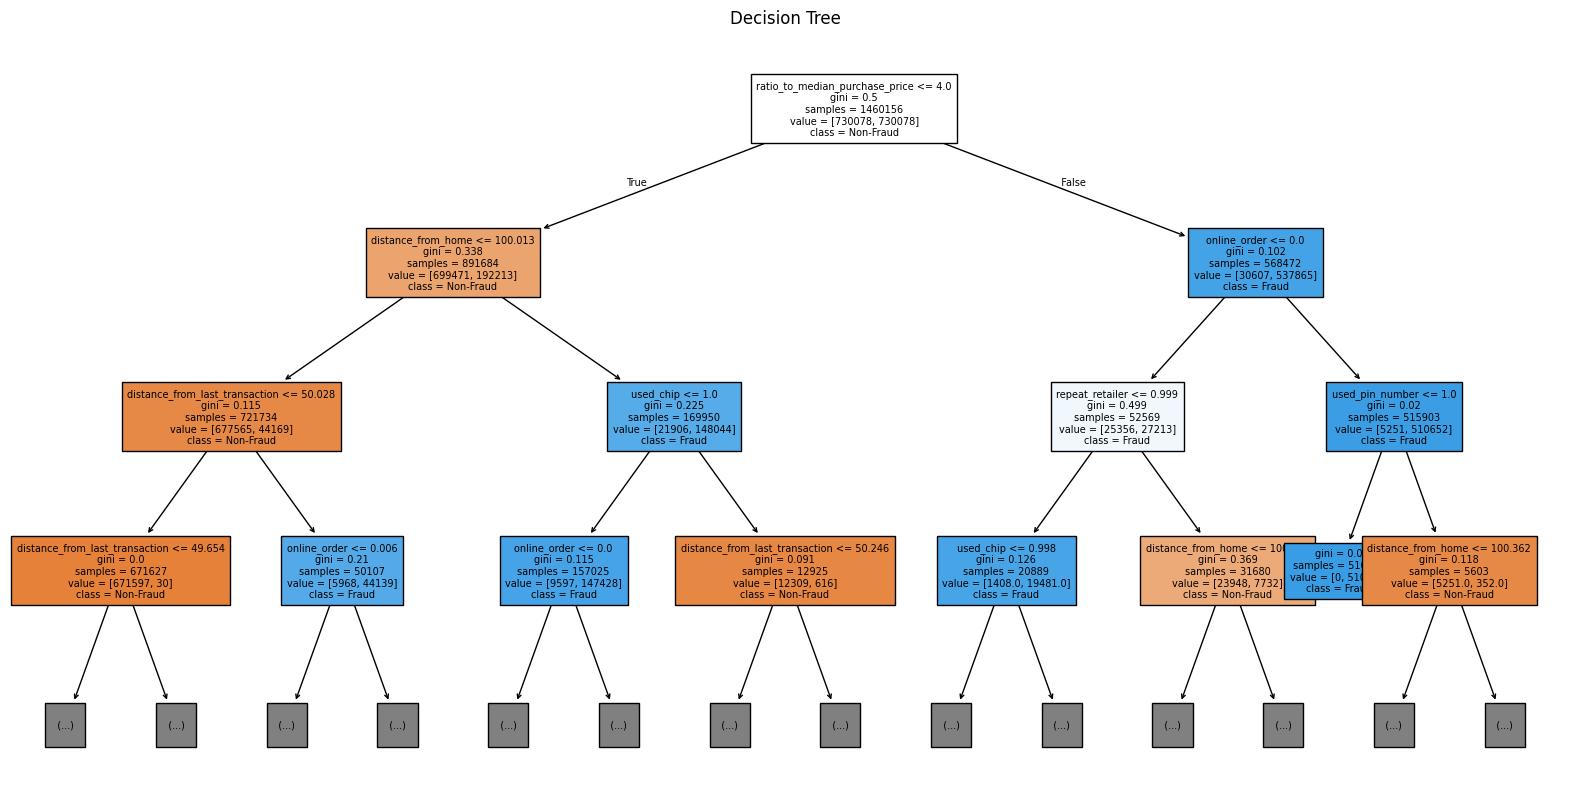

In [15]:
plt.figure(figsize=(20, 10))
plot_tree(model, feature_names= X_train_resampled.columns, class_names= ["Non-Fraud", "Fraud"], filled=True, max_depth=3, fontsize=7)
plt.title("Decision Tree")
plt.show()